In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Local input data should be placed under ./data/input/
# Generated files will be saved under ./outputs/ with subfolders for models, data, and images

import os

INPUT_DIR = os.path.join(os.getcwd(), 'data', 'input')
OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
MODEL_DIR = os.path.join(OUTPUT_DIR, 'models')
DATA_DIR = os.path.join(OUTPUT_DIR, 'data')
IMAGE_DIR = os.path.join(OUTPUT_DIR, 'images')
os.makedirs(INPUT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(IMAGE_DIR, exist_ok=True)

for dirname, _, filenames in os.walk(INPUT_DIR):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# When running locally, keep required .npy inputs in ./data/input/
# and save generated arrays, models, and figures under ./outputs/

/kaggle/input/datasets/saralizthomas/nasa-preprocessed-telemetry/X_normal_test.npy
/kaggle/input/datasets/saralizthomas/nasa-preprocessed-telemetry/X_normal_train.npy


In [2]:
import numpy as np

X_train = np.load(os.path.join(INPUT_DIR, "X_normal_train.npy"))
X_test  = np.load(os.path.join(INPUT_DIR, "X_normal_test.npy"))

print(X_train.shape)

(11008, 50, 25)


In [3]:
import torch
print(torch.cuda.is_available())

True


In [4]:
# ============================================================
# CELL 1 — Imports & GPU setup
# Paste this as a new cell after your existing preprocessing
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ── device ──────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
print(f"PyTorch: {torch.__version__}")

# ── confirm shapes from preprocessing ───────────────────────
# X_train shape: (11008, 50, 25)  — (N, timesteps, channels)
WINDOW   = X_train.shape[1]   # 50
N_CH     = X_train.shape[2]   # 25
LATENT_Z = 128                 # noise vector size
N_ATTACK_TYPES = 3             # drift | corr_break | noise_inject
print(f"Window={WINDOW}, Channels={N_CH}, Latent={LATENT_Z}")

Device : cuda
PyTorch: 2.10.0+cu128
Window=50, Channels=25, Latent=128


In [5]:
# ============================================================
# CELL 2 — Generator & Discriminator architecture
# ============================================================

class Generator(nn.Module):
    """
    Conditional 1D CNN Generator.
    Input : noise (B, LATENT_Z) + attack_type onehot (B, N_ATTACK_TYPES)
    Output: telemetry window (B, N_CH, WINDOW)  [channels-first for Conv1d]
    """
    def __init__(self, latent_z=128, n_ch=25, window=50, n_types=3):
        super().__init__()
        self.n_ch   = n_ch
        self.window = window

        # project noise + condition → small feature map
        self.fc = nn.Sequential(
            nn.Linear(latent_z + n_types, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, n_ch * 10),   # reshape to (B, n_ch, 10)
            nn.LeakyReLU(0.2),
        )

        # upsample 10 → 25 → 50 timesteps
        self.conv = nn.Sequential(
            nn.ConvTranspose1d(n_ch, 128, kernel_size=4, stride=2, padding=1),  # → 20
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose1d(128, 64, kernel_size=4, stride=2, padding=2),    # → 40? clip
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),

            nn.ConvTranspose1d(64, n_ch, kernel_size=11, stride=1, padding=5),  # fine-tune → 50
            nn.Tanh()   # output in [-1, 1], matches normalized data range
        )

    def forward(self, z, cond):
        x = torch.cat([z, cond], dim=1)       # (B, latent_z + n_types)
        x = self.fc(x)                         # (B, n_ch * 10)
        x = x.view(-1, self.n_ch, 10)         # (B, n_ch, 10)
        x = self.conv(x)                       # (B, n_ch, ~50)
        # adaptive pool to exact window size (handles rounding)
        x = torch.nn.functional.interpolate(x, size=self.window, mode='linear', align_corners=False)
        return x  # (B, N_CH, WINDOW)


class Discriminator(nn.Module):
    """
    Conditional 1D CNN Discriminator.
    Input : telemetry window (B, N_CH, WINDOW) + attack_type onehot (B, N_ATTACK_TYPES)
    Output: scalar real/fake score (B, 1)
    """
    def __init__(self, n_ch=25, window=50, n_types=3):
        super().__init__()

        self.cond_proj = nn.Linear(n_types, n_ch * window)

        self.conv = nn.Sequential(
            # input: 2*n_ch channels (signal + projected condition)
            nn.Conv1d(2 * n_ch, 64, kernel_size=5, stride=2, padding=2),   # → 25
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2),         # → 13
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Conv1d(128, 256, kernel_size=3, stride=2, padding=1),        # → 7
            nn.LeakyReLU(0.2),
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 7, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 1)
            # no sigmoid — use BCEWithLogitsLoss for numerical stability
        )

    def forward(self, x, cond):
        # x: (B, N_CH, WINDOW)
        B = x.size(0)
        c = self.cond_proj(cond).view(B, self.conv[0].in_channels // 2, -1)
        # NOTE: in_channels//2 = n_ch; just re-derive cleanly:
        c = self.cond_proj(cond).view(B, x.size(1), x.size(2))
        x = torch.cat([x, c], dim=1)   # (B, 2*N_CH, WINDOW)
        x = self.conv(x)
        return self.fc(x)


# ── instantiate & verify ─────────────────────────────────────
G = Generator(LATENT_Z, N_CH, WINDOW, N_ATTACK_TYPES).to(device)
D = Discriminator(N_CH, WINDOW, N_ATTACK_TYPES).to(device)

# quick shape test
_z  = torch.randn(4, LATENT_Z).to(device)
_c  = torch.zeros(4, N_ATTACK_TYPES).to(device); _c[:, 0] = 1.0
_gx = G(_z, _c)
_ds = D(_gx, _c)
print(f"Generator output : {_gx.shape}")   # expect (4, 25, 50)
print(f"Discriminator out: {_ds.shape}")   # expect (4, 1)
print("Architecture OK ✓")

Generator output : torch.Size([4, 25, 50])
Discriminator out: torch.Size([4, 1])
Architecture OK ✓


In [6]:
# ============================================================
# CELL 3 — DataLoader + training utilities
# ============================================================

def make_loader(X, batch_size=64, shuffle=True):
    """
    X: numpy (N, W, C)  →  tensor (N, C, W)  [channels-first for Conv1d]
    """
    t = torch.tensor(X, dtype=torch.float32).permute(0, 2, 1)  # (N, C, W)
    return DataLoader(TensorDataset(t), batch_size=batch_size,
                      shuffle=shuffle, pin_memory=(device.type == 'cuda'))

train_loader = make_loader(X_train, batch_size=64)
print(f"Train batches: {len(train_loader)}  "
      f"(~{len(train_loader)*64} samples)")

def random_condition(batch_size, n_types=N_ATTACK_TYPES):
    """One-hot condition vector, random type per batch."""
    idx = torch.randint(0, n_types, (batch_size,))
    c   = torch.zeros(batch_size, n_types)
    c[torch.arange(batch_size), idx] = 1.0
    return c.to(device)

def fixed_condition(batch_size, attack_type, n_types=N_ATTACK_TYPES):
    """One-hot for a specific attack type (0=drift,1=corr,2=noise)."""
    c = torch.zeros(batch_size, n_types)
    c[:, attack_type] = 1.0
    return c.to(device)


Train batches: 172  (~11008 samples)


In [7]:
# ============================================================
# CELL 4 — GAN Training Loop  (~200 epochs, ~90 min on T4 GPU)
# NOTE: Enable GPU in Kaggle: Settings → Accelerator → GPU T4 x2
# ============================================================

EPOCHS      = 200
LR_G        = 2e-4
LR_D        = 1e-4    # slightly lower for discriminator stability
BETA1       = 0.5     # Adam β₁ — standard for GANs
N_D_STEPS   = 2       # discriminator steps per generator step

opt_G = optim.Adam(G.parameters(), lr=LR_G, betas=(BETA1, 0.999))
opt_D = optim.Adam(D.parameters(), lr=LR_D, betas=(BETA1, 0.999))
criterion = nn.BCEWithLogitsLoss()

# LR schedulers — decay by 0.5 at epoch 100 and 150
sched_G = optim.lr_scheduler.MultiStepLR(opt_G, milestones=[100, 150], gamma=0.5)
sched_D = optim.lr_scheduler.MultiStepLR(opt_D, milestones=[100, 150], gamma=0.5)

history = {'d_loss': [], 'g_loss': [], 'epoch': []}

print("Starting GAN training...")
print(f"Epochs: {EPOCHS} | Batch: 64 | D-steps/G-step: {N_D_STEPS}")
print("-" * 50)

for epoch in range(1, EPOCHS + 1):
    G.train(); D.train()
    d_losses, g_losses = [], []

    for (real_x,) in train_loader:
        real_x = real_x.to(device)          # (B, C, W)
        B = real_x.size(0)

        real_lbl = torch.ones(B, 1).to(device)
        fake_lbl = torch.zeros(B, 1).to(device)

        # ── Train Discriminator (N_D_STEPS times) ──────────
        for _ in range(N_D_STEPS):
            opt_D.zero_grad()

            # real samples — use random conditions (D learns any type)
            cond = random_condition(B)
            d_real = D(real_x, cond)
            loss_real = criterion(d_real, real_lbl)

            # fake samples
            z    = torch.randn(B, LATENT_Z).to(device)
            fake = G(z, cond).detach()
            d_fake = D(fake, cond)
            loss_fake = criterion(d_fake, fake_lbl)

            d_loss = (loss_real + loss_fake) / 2
            d_loss.backward()
            opt_D.step()
            d_losses.append(d_loss.item())

        # ── Train Generator ─────────────────────────────────
        opt_G.zero_grad()
        cond = random_condition(B)
        z    = torch.randn(B, LATENT_Z).to(device)
        fake = G(z, cond)
        g_loss = criterion(D(fake, cond), real_lbl)   # fool discriminator
        g_loss.backward()
        opt_G.step()
        g_losses.append(g_loss.item())

    sched_G.step(); sched_D.step()

    avg_d = np.mean(d_losses)
    avg_g = np.mean(g_losses)
    history['d_loss'].append(avg_d)
    history['g_loss'].append(avg_g)
    history['epoch'].append(epoch)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch [{epoch:>3}/{EPOCHS}]  "
              f"D_loss: {avg_d:.4f}  G_loss: {avg_g:.4f}")

# save checkpoints
torch.save(G.state_dict(), os.path.join(MODEL_DIR, 'generator.pth'))
torch.save(D.state_dict(), os.path.join(MODEL_DIR, 'discriminator.pth'))
print(f"\nTraining complete. Models saved to {MODEL_DIR}")

Starting GAN training...
Epochs: 200 | Batch: 64 | D-steps/G-step: 2
--------------------------------------------------
Epoch [  1/200]  D_loss: 0.4004  G_loss: 1.6142
Epoch [ 10/200]  D_loss: 0.2028  G_loss: 2.3604
Epoch [ 20/200]  D_loss: 0.1372  G_loss: 3.7293
Epoch [ 30/200]  D_loss: 0.1235  G_loss: 3.9054
Epoch [ 40/200]  D_loss: 0.1147  G_loss: 4.1033
Epoch [ 50/200]  D_loss: 0.1154  G_loss: 4.1108
Epoch [ 60/200]  D_loss: 0.1177  G_loss: 4.1841
Epoch [ 70/200]  D_loss: 0.1217  G_loss: 4.5429
Epoch [ 80/200]  D_loss: 0.1135  G_loss: 4.1925
Epoch [ 90/200]  D_loss: 0.1140  G_loss: 3.8012
Epoch [100/200]  D_loss: 0.1357  G_loss: 4.1071
Epoch [110/200]  D_loss: 0.0949  G_loss: 4.3885
Epoch [120/200]  D_loss: 0.0906  G_loss: 4.4165
Epoch [130/200]  D_loss: 0.1016  G_loss: 4.2087
Epoch [140/200]  D_loss: 0.0884  G_loss: 4.7388
Epoch [150/200]  D_loss: 0.0852  G_loss: 4.9151
Epoch [160/200]  D_loss: 0.0752  G_loss: 4.6928
Epoch [170/200]  D_loss: 0.0699  G_loss: 5.0230
Epoch [180/200] 

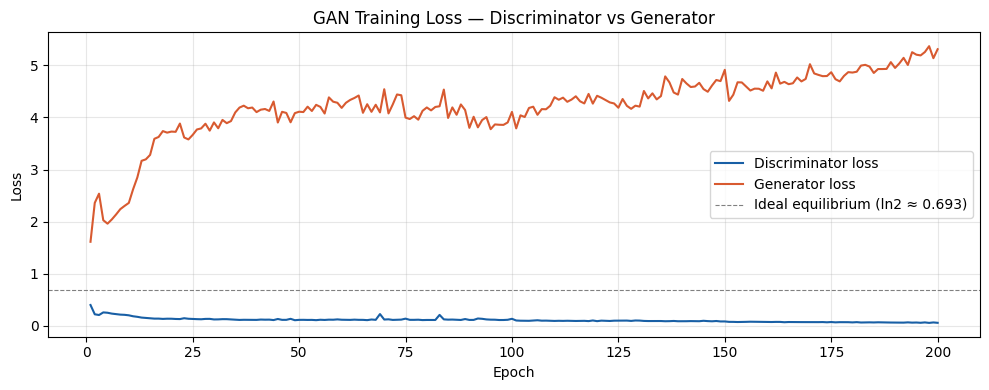

Loss curve saved.


In [8]:
# ============================================================
# CELL 5 — Training loss plot
# ============================================================

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history['epoch'], history['d_loss'], label='Discriminator loss',
        color='#185FA5', linewidth=1.5)
ax.plot(history['epoch'], history['g_loss'], label='Generator loss',
        color='#D85A30', linewidth=1.5)
ax.axhline(y=0.693, color='gray', linestyle='--', linewidth=0.8,
           label='Ideal equilibrium (ln2 ≈ 0.693)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('GAN Training Loss — Discriminator vs Generator')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(IMAGE_DIR, 'gan_training_loss.png'), dpi=150)
plt.show()
print("Loss curve saved.")

In [9]:
# ============================================================
# CELL 6 — Physics-Constrained Attack Generation
#
# 3 attack types, each with 5 physics constraints:
#  1. Temporal smoothness  (Gaussian smoothing)
#  2. Bounded variation    (hard clip to training range)
#  3. Slow drift           (multiplicative ramp)
#  4. Correlation preserve (soft — via GAN training on real data)
#  5. Stealth              (deviation ≤ 3σ of training data)
# ============================================================

# ── Pre-compute training statistics for stealth constraint ──
train_mean = X_train.mean(axis=(0, 1))   # (25,)
train_std  = X_train.std(axis=(0, 1))    # (25,)
STEALTH_SIGMA = 3.0                       # max allowed deviation in σ units

# ── Correlation matrix from normal data ─────────────────────
X_flat_corr = X_train.reshape(-1, N_CH)  # (N*W, 25)
corr_matrix  = np.corrcoef(X_flat_corr.T)  # (25, 25)

print(f"Training stats computed.")
print(f"Mean range: [{train_mean.min():.3f}, {train_mean.max():.3f}]")
print(f"Std  range: [{train_std.min():.3f},  {train_std.max():.3f}]")


def apply_physics_constraints(window_np, attack_type,
                               train_mean=train_mean,
                               train_std=train_std,
                               stealth_sigma=STEALTH_SIGMA):
    """
    Apply 5 physics-inspired constraints to a generated window.

    Parameters
    ----------
    window_np  : np.ndarray (W, C)  — raw GAN output, channels-last
    attack_type: int  0=drift | 1=corr_break | 2=noise_inject
    Returns
    -------
    constrained: np.ndarray (W, C)
    meta       : dict  — constraint diagnostics
    """
    W, C = window_np.shape
    out  = window_np.copy()
    meta = {}

    # ── CONSTRAINT 1: Temporal smoothness ───────────────────
    # Gaussian filter along time axis per channel
    sigma_smooth = 2.0 if attack_type != 2 else 0.5   # noise attack: less smoothing
    for c in range(C):
        out[:, c] = gaussian_filter1d(out[:, c], sigma=sigma_smooth)
    meta['smoothing_sigma'] = sigma_smooth

    # ── CONSTRAINT 2 + 5: Bounded variation + Stealth ───────
    # Clip each channel to [mean ± stealth_sigma * std]
    lo = train_mean - stealth_sigma * train_std
    hi = train_mean + stealth_sigma * train_std
    out = np.clip(out, lo[np.newaxis, :], hi[np.newaxis, :])
    meta['stealth_clip'] = f"±{stealth_sigma}σ"

    # ── CONSTRAINT 3: Attack-type specific perturbations ────
    if attack_type == 0:
        # SLOW DRIFT — ramp that grows linearly over window
        # Affects a random subset of channels (simulating sensor group failure)
        n_affected = max(3, C // 4)
        affected_ch = np.random.choice(C, n_affected, replace=False)
        ramp = np.linspace(0, 1, W)[:, np.newaxis]          # (W, 1)
        drift_mag = 0.5 * train_std[affected_ch]             # 0.5σ max drift
        for i, ch in enumerate(affected_ch):
            out[:, ch] += ramp[:, 0] * drift_mag[i]
        meta['attack'] = 'slow_drift'
        meta['affected_channels'] = affected_ch.tolist()
        meta['drift_magnitude'] = drift_mag.tolist()

    elif attack_type == 1:
        # CORRELATION BREAK — perturb correlated channel pairs in opposite directions
        # Find top correlated pairs from training correlation matrix
        corr_upper = np.triu(np.abs(corr_matrix), k=1)
        top_pairs  = np.argwhere(corr_upper > 0.5)[:5]      # up to 5 correlated pairs

        for pair in top_pairs:
            c1, c2 = pair
            # push them in opposite directions — breaks correlation
            t = np.linspace(-1, 1, W)
            noise_scale = 0.3 * train_std[c1]
            out[:, c1] += t * noise_scale
            out[:, c2] -= t * noise_scale * 0.8
        meta['attack'] = 'correlation_break'
        meta['broken_pairs'] = top_pairs.tolist() if len(top_pairs) > 0 else []

    elif attack_type == 2:
        # NOISE INJECTION — add time-varying noise above normal noise floor
        noise_scale = 0.4 * train_std[np.newaxis, :]        # per-channel
        # Noise grows in the second half of the window (late-onset stealthy attack)
        onset = np.zeros(W)
        onset[W//2:] = np.linspace(0, 1, W - W//2)
        injected = onset[:, np.newaxis] * np.random.randn(W, C) * noise_scale
        out += injected
        meta['attack'] = 'noise_injection'
        meta['onset_timestep'] = W // 2

    # ── Final stealth re-clip after perturbations ────────────
    out = np.clip(out, lo[np.newaxis, :], hi[np.newaxis, :])

    # ── CONSTRAINT 4 diagnostics: measure correlation change ─
    corr_after = np.nan_to_num(np.corrcoef(out.T))
    corr_delta = np.abs(corr_matrix - corr_after).mean()
    meta['mean_corr_delta'] = float(corr_delta)

    return out.astype(np.float32), meta


# ── Quick test of constraints ────────────────────────────────
_dummy = np.random.randn(WINDOW, N_CH).astype(np.float32) * 0.3
for at in range(3):
    _out, _meta = apply_physics_constraints(_dummy, at)
    print(f"Attack type {at}: {_meta['attack']:20s} | "
          f"corr_delta={_meta['mean_corr_delta']:.4f} | "
          f"shape={_out.shape}")


Training stats computed.
Mean range: [-0.259, 0.078]
Std  range: [0.000,  1.079]
Attack type 0: slow_drift           | corr_delta=nan | shape=(50, 25)
Attack type 1: correlation_break    | corr_delta=nan | shape=(50, 25)
Attack type 2: noise_injection      | corr_delta=nan | shape=(50, 25)


In [10]:
# ============================================================
# CELL 7 — Generate synthetic attack dataset
# ============================================================

G.eval()

N_SYNTHETIC_PER_TYPE = 2000   # 2000 × 3 = 6000 synthetic attack windows
ATTACK_NAMES = {0: 'slow_drift', 1: 'corr_break', 2: 'noise_inject'}

synthetic_windows = []   # list of (W, C) arrays
synthetic_labels  = []   # 1 = attack
synthetic_types   = []   # 0/1/2
synthetic_metas   = []   # diagnostics

print("Generating synthetic attack telemetry...")

with torch.no_grad():
    for attack_type in range(N_ATTACK_TYPES):
        type_windows = []

        # generate in batches of 64
        remaining = N_SYNTHETIC_PER_TYPE
        while remaining > 0:
            bsz = min(64, remaining)
            z    = torch.randn(bsz, LATENT_Z).to(device)
            cond = fixed_condition(bsz, attack_type)
            fake = G(z, cond)                          # (B, C, W)
            fake_np = fake.cpu().numpy().transpose(0, 2, 1)  # (B, W, C)

            for i in range(bsz):
                constrained, meta = apply_physics_constraints(
                    fake_np[i], attack_type)
                type_windows.append(constrained)
                synthetic_metas.append(meta)

            remaining -= bsz

        synthetic_windows.extend(type_windows)
        synthetic_labels.extend([1] * N_SYNTHETIC_PER_TYPE)
        synthetic_types.extend([attack_type] * N_SYNTHETIC_PER_TYPE)

        print(f"  [{ATTACK_NAMES[attack_type]:15s}] "
              f"{N_SYNTHETIC_PER_TYPE} windows generated ✓")

# ── Stack into arrays ────────────────────────────────────────
syn_X = np.array(synthetic_windows)   # (6000, 50, 25)
syn_y = np.array(synthetic_labels)    # (6000,)
syn_t = np.array(synthetic_types)     # (6000,)

print(f"\nSynthetic dataset: {syn_X.shape}")
print(f"Labels: {np.unique(syn_y, return_counts=True)}")
print(f"Types : {np.unique(syn_t, return_counts=True)}")

# ── Save to disk ─────────────────────────────────────────────
np.save(os.path.join(DATA_DIR, 'synthetic_attacks.npy'),  syn_X)
np.save(os.path.join(DATA_DIR, 'synthetic_labels.npy'),   syn_y)
np.save(os.path.join(DATA_DIR, 'synthetic_types.npy'),    syn_t)
print(f"\nSynthetic data saved to {DATA_DIR}")


Generating synthetic attack telemetry...
  [slow_drift     ] 2000 windows generated ✓
  [corr_break     ] 2000 windows generated ✓
  [noise_inject   ] 2000 windows generated ✓

Synthetic dataset: (6000, 50, 25)
Labels: (array([1]), array([6000]))
Types : (array([0, 1, 2]), array([2000, 2000, 2000]))

Synthetic data saved to /kaggle/working/


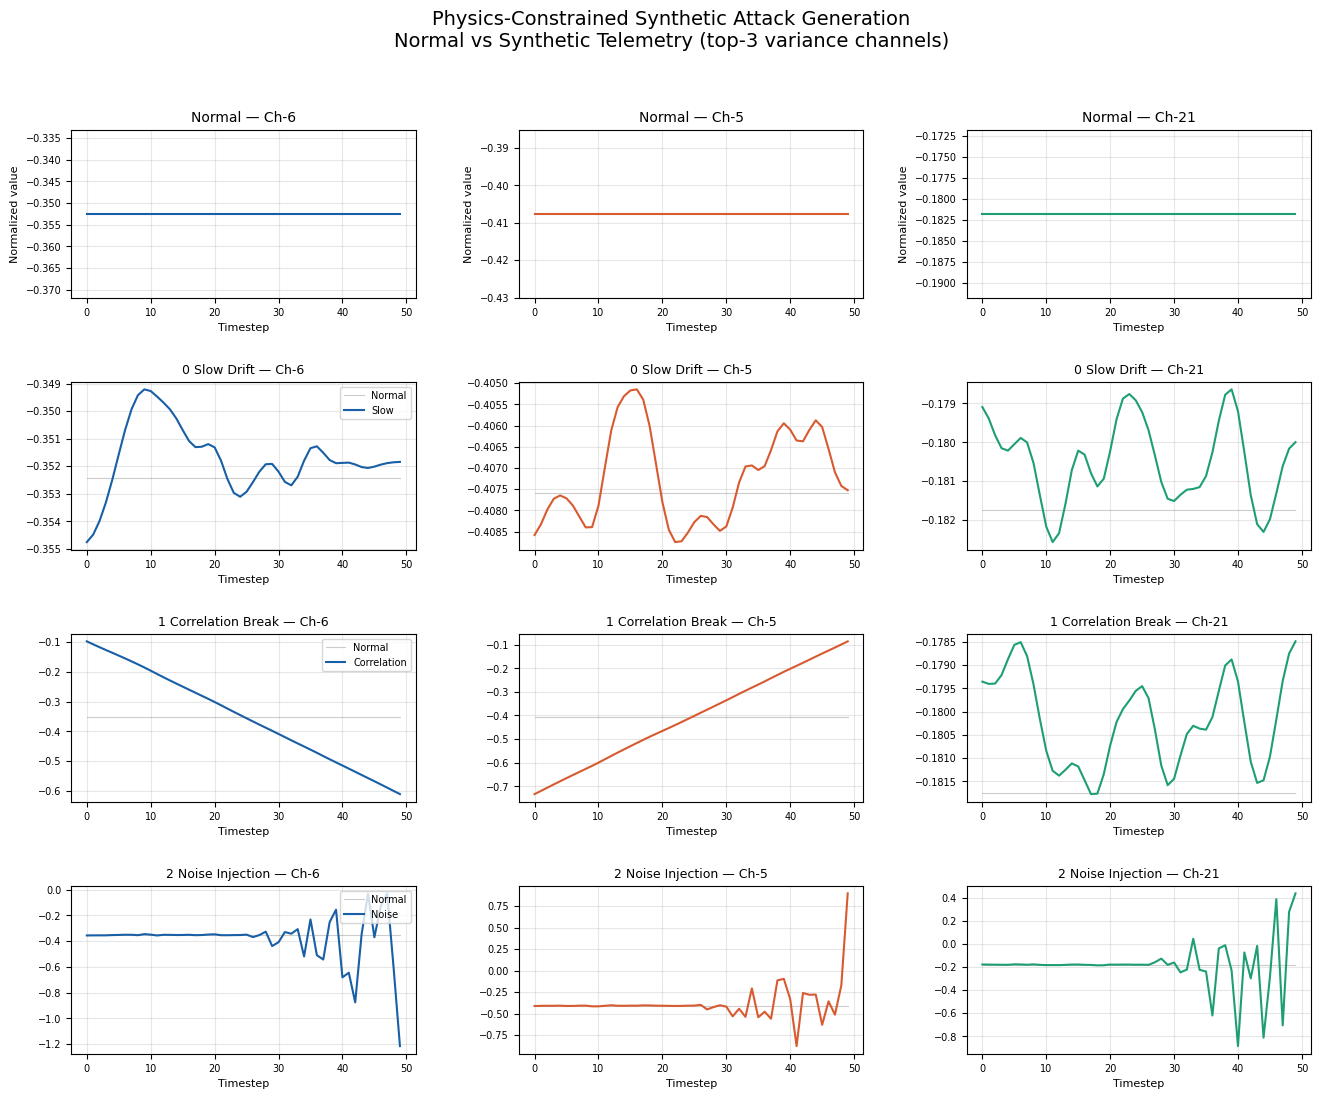

Visualization saved: outputs/images/normal_vs_attacks.png


In [11]:
# ============================================================
# CELL 8 — Sanity visualization: Normal vs each attack type
# ============================================================

# pick a random normal window for comparison
normal_sample = X_train[np.random.randint(len(X_train))]  # (50, 25)

# pick 3 channels with high variance for clear visual
top_ch_idx = np.argsort(X_train.std(axis=(0, 1)))[-3:][::-1]
ch_names   = [f"Ch-{i}" for i in top_ch_idx]
colors     = ['#185FA5', '#D85A30', '#1D9E75']

fig = plt.figure(figsize=(16, 12))
fig.suptitle('Physics-Constrained Synthetic Attack Generation\n'
             'Normal vs Synthetic Telemetry (top-3 variance channels)',
             fontsize=14, fontweight='normal', y=0.98)

gs = gridspec.GridSpec(4, 3, hspace=0.5, wspace=0.3)

# Row 0: Normal telemetry
for ci, (ch, col) in enumerate(zip(top_ch_idx, colors)):
    ax = fig.add_subplot(gs[0, ci])
    ax.plot(normal_sample[:, ch], color=col, linewidth=1.5)
    ax.set_title(f'Normal — {ch_names[ci]}', fontsize=10)
    ax.set_ylabel('Normalized value', fontsize=8)
    ax.set_xlabel('Timestep', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=7)

# Rows 1-3: Each attack type
for at_idx, (at_name, at_label) in enumerate(
        [('Slow Drift (type 0)', 0),
         ('Correlation Break (type 1)', 1),
         ('Noise Injection (type 2)', 2)]):

    # get a representative sample of this type
    mask    = syn_t == at_label
    samples = syn_X[mask]
    sample  = samples[np.random.randint(len(samples))]   # (50, 25)

    for ci, (ch, col) in enumerate(zip(top_ch_idx, colors)):
        ax = fig.add_subplot(gs[at_idx + 1, ci])
        # overlay normal (faint) and attack (solid)
        ax.plot(normal_sample[:, ch], color='gray',
                linewidth=0.8, alpha=0.4, label='Normal')
        ax.plot(sample[:, ch], color=col,
                linewidth=1.5, label=at_name.split(' ')[0])
        ax.set_title(f'{at_label} {at_name.split("(")[0].strip()} — {ch_names[ci]}',
                     fontsize=9)
        ax.set_xlabel('Timestep', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=7)
        if ci == 0:
            ax.legend(fontsize=7, loc='upper right')

plt.savefig(os.path.join(IMAGE_DIR, 'normal_vs_attacks.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"Visualization saved: {os.path.join(IMAGE_DIR, 'normal_vs_attacks.png')}")



In [12]:
# ============================================================
# CELL 9 — Constraint verification: stealth & correlation stats
# ============================================================

print("=" * 55)
print("PHYSICS CONSTRAINT VERIFICATION REPORT")
print("=" * 55)

for at_type in range(N_ATTACK_TYPES):
    mask    = syn_t == at_type
    samples = syn_X[mask]   # (2000, 50, 25)
    name    = ATTACK_NAMES[at_type]

    # stealth: max deviation from training mean in σ units
    deviations = np.abs(
        (samples - train_mean[np.newaxis, np.newaxis, :])
        / (train_std[np.newaxis, np.newaxis, :] + 1e-8)
    )
    max_dev  = deviations.max()
    mean_dev = deviations.mean()

    # temporal smoothness: mean abs diff between consecutive timesteps
    diffs    = np.abs(np.diff(samples, axis=1))   # (N, W-1, C)
    smoothness = diffs.mean()

    # correlation delta
    type_metas  = [m for m, t in zip(synthetic_metas, syn_t) if t == at_type]
    corr_deltas = [m['mean_corr_delta'] for m in type_metas]
    avg_corr_d  = np.mean(corr_deltas)

    print(f"\n  Attack: {name}")
    print(f"    Stealth — max deviation : {max_dev:.3f}σ  "
          f"(limit: {STEALTH_SIGMA}σ) {'✓' if max_dev <= STEALTH_SIGMA else '✗'}")
    print(f"    Stealth — mean deviation: {mean_dev:.3f}σ")
    print(f"    Smoothness (mean |Δt|)  : {smoothness:.4f}")
    print(f"    Correlation delta (avg) : {avg_corr_d:.4f}")

print("\n" + "=" * 55)
print("Dataset summary")
print(f"  Normal windows (train)  : {len(X_train)}")
print(f"  Synthetic attack windows: {len(syn_X)}")
print(f"  Total augmented dataset : {len(X_train) + len(syn_X)}")
print("=" * 55)
print("\nPhase 1 complete: GAN trained + synthetic data generated.")
print("Next: build augmented autoencoder + anomaly detection.")


PHYSICS CONSTRAINT VERIFICATION REPORT

  Attack: slow_drift
    Stealth — max deviation : 3.000σ  (limit: 3.0σ) ✓
    Stealth — mean deviation: 0.133σ
    Smoothness (mean |Δt|)  : 0.0023
    Correlation delta (avg) : nan

  Attack: corr_break
    Stealth — max deviation : 3.000σ  (limit: 3.0σ) ✓
    Stealth — mean deviation: 0.156σ
    Smoothness (mean |Δt|)  : 0.0039
    Correlation delta (avg) : nan

  Attack: noise_inject
    Stealth — max deviation : 3.000σ  (limit: 3.0σ) ✓
    Stealth — mean deviation: 0.162σ
    Smoothness (mean |Δt|)  : 0.0511
    Correlation delta (avg) : nan

Dataset summary
  Normal windows (train)  : 11008
  Synthetic attack windows: 6000
  Total augmented dataset : 17008

Phase 1 complete: GAN trained + synthetic data generated.
Next: build augmented autoencoder + anomaly detection.
